In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pyccl as ccl
from classy import Class

We want to compare the matter power spectrum as output manually from class with massive neutrinos nonzero to the power spectrum as output from class via ccl for the same parameters. This is a sanity check.

Testing model 1...
mnu =  [0.04, 0.0, 0.0]
(w0, wa) =  (-1.0, 0.0)


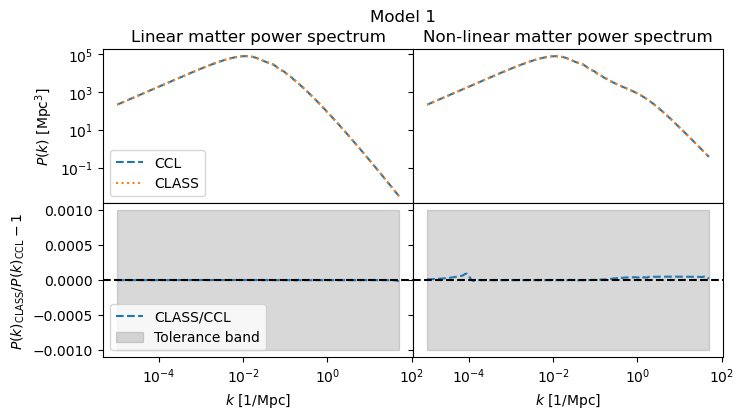

Testing model 2...
mnu =  [0.05, 0.01, 0.0]
(w0, wa) =  (-0.9, 0.0)


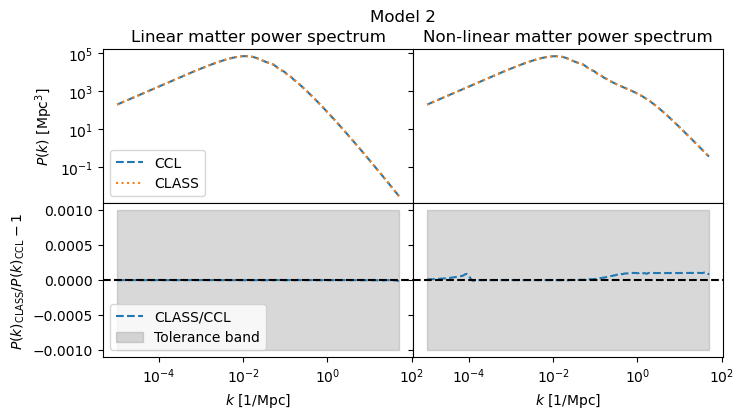

Testing model 3...
mnu =  [0.03, 0.02, 0.04]
(w0, wa) =  (-0.9, 0.1)


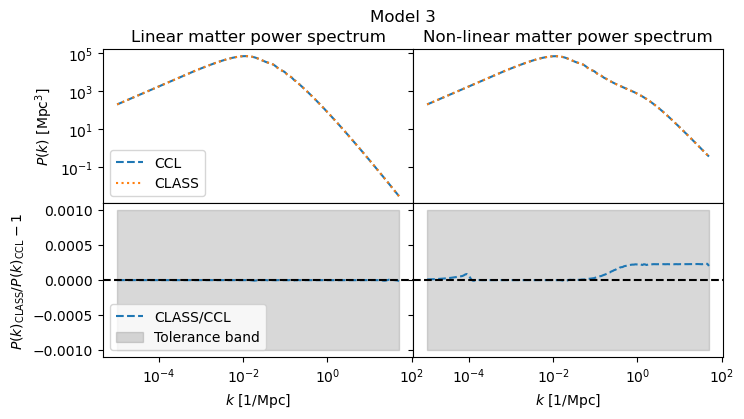

In [2]:
# Copied from benchmarks/test_pk_nu.py

KMIN = 1e-5
KMAX = 50
POWER_NU_TOL = 0.001
k_arr = np.logspace(np.log10(KMIN), np.log10(KMAX), 200)

mnu = [[0.04, 0., 0.],
        [0.05, 0.01, 0.],
        [0.03, 0.02, 0.04]]
w_0 = [-1.0, -0.9, -0.9]
w_a = [0.0, 0.0, 0.1]

for model in range(3):
    print("Testing model %d..." % (model+1))
    print("mnu = ", mnu[model])
    print("(w0, wa) = ", f"({w_0[model]}, {w_a[model]})")


    cosmo = ccl.Cosmology(
        Omega_c=0.25,
        Omega_b=0.05,
        h=0.7,
        A_s=2.1e-9,
        n_s=0.96,
        Neff=3.046,  # In CLASSv3, Neff=3.044.
        T_CMB=2.725,
        Omega_k=0,
        w0=w_0[model],
        wa=w_a[model],
        m_nu=mnu[model],
        mass_split='list',
        transfer_function='boltzmann_class')

    a = 1
    z = 1/a - 1
    k_arr = np.logspace(np.log10(KMIN), np.log10(KMAX), 200)

    # Instantiate CLASS for comparison
    # Generate pk from CLASS
    N_ncdm = np.nonzero(mnu[model])[0].size
    # N_ur = [3.044, 2.0308, 1.0176, 0.00441][N_ncdm]  # Values in explanatori.ini
    # N_ur ~ N_eff - N_ncdm * T_ncdm^4 * (11/4)^(4/3), with T_ncdm = 0.71611 in CLASS
    N_ur = cosmo['Neff'] - 1.0132 * N_ncdm
    params = {'Omega_Lambda': 0,
            # 'Omega_fld': 0,  # Left unespecified to use w0, wa
            # Dark energy parameters
            'w0_fld': w_0[model],
            'wa_fld': w_a[model],
            # Cosmological parameters
            'h': cosmo['h'],
            'Omega_cdm': cosmo['Omega_c'],
            'Omega_b': cosmo['Omega_b'],
            'A_s': cosmo['A_s'],
            'n_s': cosmo['n_s'],
            'T_cmb': cosmo['T_CMB'],
            'Omega_k': cosmo['Omega_k'],
            # Neutrinos
            "N_ur": N_ur,  # Neff
            "N_ncdm": N_ncdm,  # Number of massive neutrino species
            "m_ncdm": ",".join([str(m) for m in mnu[model][:N_ncdm]]),  # m_nu
            # Matter power spectrum
            'non_linear': 'halofit',
            'output': 'mPk',
            'P_k_max_1/Mpc': KMAX,
            'z_pk': z
            }

    cosmo_classy = Class()
    cosmo_classy.set(params)
    cosmo_classy.compute()
    
    # Generate pk from CLASS and compare to CCL
    pk_lin = np.array([cosmo_classy.pk_lin(k_i, z) for k_i in k_arr])
    pk_nl = np.array([cosmo_classy.pk(k_i, z) for k_i in k_arr])
    cosmo_classy.struct_cleanup()  # Free memory used by CLASS

    # Linear Pk
    pk_lin_ccl = ccl.linear_matter_power(cosmo, k_arr, a)

    # Non-linear Pk
    pk_nl_ccl = ccl.nonlin_matter_power(cosmo, k_arr, a)


    # Plot Pk's and reldevs 
    f, ax = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey='row', gridspec_kw={'hspace': 0.0, 'wspace': 0.0})

    # Linear Pk
    ax[0, 0].plot(k_arr, pk_lin_ccl, label='CCL', ls='--')
    ax[0, 0].plot(k_arr, pk_lin, label='CLASS', ls=':')
    ax[0, 0].set_xscale('log')
    ax[0, 0].set_yscale('log')
#     ax[0, 0].set_xlabel(r'$k$ [1/Mpc]')
    ax[0, 0].set_ylabel(r'$P(k)$ [Mpc$^3$]')
    ax[0, 0].legend()

    ax[1, 0].plot(k_arr, pk_lin/ pk_lin_ccl -1, label='CLASS/CCL', ls='--')

    # Add band with tolerance
    ax[1, 0].axhline(0, color='k', ls='--')
    ax[1, 0].fill_between(k_arr, -POWER_NU_TOL, POWER_NU_TOL, color='gray', alpha=0.3, label='Tolerance band')

    ax[1, 0].set_xscale('log')
    ax[1, 0].set_yscale('linear')
    ax[1, 0].set_xlabel(r'$k$ [1/Mpc]')
    ax[1, 0].set_ylabel(r'$P(k)_{\rm CLASS}/P(k)_{\rm CCL} - 1$')
    ax[0, 0].set_title('Linear matter power spectrum')
    ax[1, 0].legend()

    # Non-linear Pk
    ax[0, 1].plot(k_arr, pk_nl_ccl, label='CCL', ls='--')
    ax[0, 1].plot(k_arr, pk_nl, label='CLASS ', ls=':')
    ax[0, 1].set_xscale('log')
    ax[0, 1].set_yscale('log')
    ax[0, 1].set_xlabel(r'$k$ [1/Mpc]')
#     ax[0, 1].set_ylabel(r'$P(k)$ [Mpc$^3$]')
#     ax[0, 1].legend()
    ax[1, 1].plot(k_arr, pk_nl/ pk_nl_ccl -1, label='CLASS/CCL', ls='--')

    # Add band with tolerance
    ax[1, 1].axhline(0, color='k', ls='--')
    ax[1, 1].fill_between(k_arr, -POWER_NU_TOL, POWER_NU_TOL, color='gray', alpha=0.3, label='Tolerance band')

    ax[1, 1].set_xscale('log')
    ax[1, 1].set_yscale('linear')
    ax[1, 1].set_xlabel(r'$k$ [1/Mpc]')
#     ax[1, 1].set_ylabel(r'$P(k)_{\rm CLASS}/P(k)_{\rm CCL} - 1$')
    ax[0, 1].set_title('Non-linear matter power spectrum')
#     ax[1, 1].legend()

    f.suptitle('Model %d' % (model+1))
    plt.show()
    plt.close()